#  Iris Recognition — VGG16 Siamese Neural Network

This notebook implements iris biometric verification using a **VGG16-backbone Siamese Network** trained with **Contrastive Loss**.  It follows the same pipeline as the ResNet18 baseline and is designed for direct comparison.

Dataset: Dobeš-Machala Iris Database
> Dobeš, M., Martinek J., Skoupil D., Dobešová Z., Pospíšil J., *Human eye localization using the modified Hough transform*. Optik, 117(10), 468-473, Elsevier 2006.
> Dobeš M., Machala L., *Human Eye Iris Recognition Using the Mutual Information*. Optik 115(9), 399-405, Elsevier 2004.
> http://phoenix.inf.upol.cz/iris/

Uploaded to Kaggle by OUARAS Khelil Rafik

## 1. Imports

In [1]:
import kagglehub
import os
import re
import random
import numpy as np
from pathlib import Path
from itertools import combinations
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

## 2. Download Dataset

In [2]:
path = kagglehub.dataset_download("ouaraskhelilrafik/iris-images")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ouaraskhelilrafik/iris-images


## 3. Configuration

In [3]:
CFG = {
    "data_root":    f"{path}/iris_images",
    "img_size":     224,
    "embed_dim":    128,
    "margin":       1.0,
    "batch_size":   32,
    "epochs":       20,
    "lr":           1e-4,
    "seed":         42,
    "train_ratio":  0.75,
    "val_ratio":    0.10,
    "pairs_per_id": 4,
    "device":       "cuda" if torch.cuda.is_available() else "cpu",
}

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
print(f'Device: {CFG["device"]}')

Device: cuda


## 4. Data Utilities

### 4.1 Parse dataset

In [4]:
def parse_dataset(data_root: str) -> dict[str, list[str]]:
    identity_images = defaultdict(list)
    data_root = Path(data_root)

    for img_path in sorted(data_root.rglob("*.png")):
        filename = img_path.stem
        m = re.match(r"(\d+)([LR])", filename)
        if m:
            person_id, side = m.group(1), m.group(2)
            identity = f"{person_id}{side}"
        else:
            parts = img_path.parts
            folder   = parts[-3] if len(parts) >= 3 else "unknown"
            side_dir = parts[-2] if len(parts) >= 2 else "unknown"
            identity = f"{folder}_{side_dir[0].upper()}"

        identity_images[identity].append(str(img_path))

    identity_images = {k: v for k, v in identity_images.items() if len(v) >= 2}
    print(f"Found {len(identity_images)} identities, "
          f"{sum(len(v) for v in identity_images.values())} images total.")
    return identity_images

### 4.2 Split identities into train / val / test

In [5]:
def split_identities(identity_images: dict, cfg: dict) -> tuple[dict, dict, dict]:
    ids = list(identity_images.keys())
    random.shuffle(ids)

    n        = len(ids)
    n_train  = int(n * cfg["train_ratio"])
    n_val    = int(n * cfg["val_ratio"])

    train_ids = ids[:n_train]
    val_ids   = ids[n_train : n_train + n_val]
    test_ids  = ids[n_train + n_val :]

    train_data = {k: identity_images[k] for k in train_ids}
    val_data   = {k: identity_images[k] for k in val_ids}
    test_data  = {k: identity_images[k] for k in test_ids}

    print(f"Split — train: {len(train_data)} ids | "
          f"val: {len(val_data)} ids | test: {len(test_data)} ids")
    return train_data, val_data, test_data

### 4.3 Generate positive and negative pairs

In [6]:
def generate_pairs(identity_images: dict, pairs_per_id: int = 4) -> list[tuple]:
    all_ids   = list(identity_images.keys())
    pos_pairs = []
    neg_pairs = []

    for identity, images in identity_images.items():
        combos  = list(combinations(images, 2))
        sampled = random.sample(combos, min(pairs_per_id, len(combos)))
        for img1, img2 in sampled:
            pos_pairs.append((img1, img2, 1))

    n_neg = len(pos_pairs)
    while len(neg_pairs) < n_neg:
        id1, id2 = random.sample(all_ids, 2)
        img1 = random.choice(identity_images[id1])
        img2 = random.choice(identity_images[id2])
        neg_pairs.append((img1, img2, 0))

    pairs = pos_pairs + neg_pairs
    random.shuffle(pairs)
    print(f"  Generated {len(pos_pairs)} positive + {len(neg_pairs)} negative pairs")
    return pairs

### 4.4 Image transforms

In [7]:
def get_transforms(img_size: int, train: bool) -> transforms.Compose:
    base = [
        transforms.Resize((img_size, img_size)),
        transforms.Grayscale(num_output_channels=3),
    ]
    if train:
        aug = [
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.3),
        ]
    else:
        aug = []
    post = [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
    return transforms.Compose(base + aug + post)

### 4.5 Iris pair dataset

In [8]:
class IrisPairDataset(Dataset):
    def __init__(self, pairs: list[tuple], transform: transforms.Compose):
        self.pairs     = pairs
        self.transform = transform

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        path1, path2, label = self.pairs[idx]
        img1 = self.transform(Image.open(path1).convert("L"))
        img2 = self.transform(Image.open(path2).convert("L"))
        return img1, img2, torch.tensor(label, dtype=torch.float32)

## 5. Model Architecture

### 5.1 Embedding network (VGG16 backbone)

We replace the ResNet18 backbone used in the baseline with **VGG16** (Simonyan & Zisserman, 2014). VGG16 is a 16-layer sequential convolutional network made of uniform 3×3 conv blocks and max-pooling layers, pre-trained on ImageNet.

**Architecture changes vs ResNet18 baseline:**
- Backbone: `torchvision.models.vgg16` (features + adaptive avg pool)
- Flattened feature dimension: 25 088 → 4 096 (FC1, ReLU, Dropout 0.5) → 128 (FC2)
- L2 normalisation on the output embedding (same as baseline)
- Parameters: ~138.36 M (vs ~11.24 M for ResNet18)

In [9]:
class EmbeddingNet(nn.Module):
    """
    VGG16-based embedding network.

    Architecture:
        VGG16 features (13 conv layers + max-pool)
        → AdaptiveAvgPool2d(7,7)
        → Flatten
        → Linear(25088 → 4096) + ReLU + Dropout(0.5)
        → Linear(4096  → embed_dim)
        → L2 normalisation
    """
    def __init__(self, embed_dim: int = 128):
        super().__init__()
        backbone = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

        # Reuse VGG16 convolutional feature extractor + adaptive pool
        self.features = backbone.features          # 13 conv layers
        self.avgpool  = backbone.avgpool           # AdaptiveAvgPool2d(7,7)

        # Custom embedding head
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, embed_dim),
            nn.BatchNorm1d(embed_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = self.head(x)
        return F.normalize(x, p=2, dim=1)   # L2-normalised embedding


net = EmbeddingNet(embed_dim=CFG["embed_dim"])
total_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"EmbeddingNet (VGG16) — trainable parameters: {total_params:,}")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 175MB/s]  


EmbeddingNet (VGG16) — trainable parameters: 118,003,904


### 5.2 Siamese network

In [10]:
class SiameseNet(nn.Module):
    """Weight-shared Siamese wrapper around EmbeddingNet."""
    def __init__(self, embed_dim: int = 128):
        super().__init__()
        self.embedding_net = EmbeddingNet(embed_dim)

    def forward(self, img1: torch.Tensor, img2: torch.Tensor):
        return self.embedding_net(img1), self.embedding_net(img2)

### 5.3 Contrastive loss

In [11]:
class ContrastiveLoss(nn.Module):
    """
    Contrastive Loss (Hadsell et al., 2006):
        L = y * d^2  +  (1-y) * max(margin - d, 0)^2

    where d = ||emb1 - emb2||_2  and  y=1 for same-identity pairs.
    """
    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(
        self,
        emb1:  torch.Tensor,
        emb2:  torch.Tensor,
        label: torch.Tensor,
    ) -> torch.Tensor:
        dist     = F.pairwise_distance(emb1, emb2)
        pos_loss = label * dist.pow(2)
        neg_loss = (1 - label) * F.relu(self.margin - dist).pow(2)
        return (pos_loss + neg_loss).mean()

## 6. Training Helpers

### 6.1 Accuracy calculation

In [12]:
def compute_accuracy(emb1, emb2, labels, threshold: float = 0.5) -> float:
    dist = F.pairwise_distance(emb1, emb2).detach().cpu()
    return ((dist < threshold).float() == labels.cpu()).float().mean().item()

### 6.2 Single epoch training step

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_acc = 0.0, 0.0
    for img1, img2, labels in loader:
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
        optimizer.zero_grad()
        emb1, emb2 = model(img1, img2)
        loss = criterion(emb1, emb2, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc  += compute_accuracy(emb1, emb2, labels)
    return total_loss / len(loader), total_acc / len(loader)

### 6.3 Evaluation step

In [14]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc = 0.0, 0.0
    for img1, img2, labels in loader:
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
        emb1, emb2 = model(img1, img2)
        loss = criterion(emb1, emb2, labels)
        total_loss += loss.item()
        total_acc  += compute_accuracy(emb1, emb2, labels)
    return total_loss / len(loader), total_acc / len(loader)

### 6.4 Full training loop

In [15]:
def train(model, train_loader, val_loader, cfg):
    device    = cfg["device"]
    criterion = ContrastiveLoss(margin=cfg["margin"]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=3, factor=0.5
    )

    history       = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")

    for epoch in range(1, cfg["epochs"] + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl_loss)

        for k, v in zip(history.keys(), [tr_loss, vl_loss, tr_acc, vl_acc]):
            history[k].append(v)

        print(f"Epoch {epoch:3d}/{cfg['epochs']}  "
              f"train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"val loss {vl_loss:.4f} acc {vl_acc:.3f}")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            torch.save(model.state_dict(), "best_siamese_vgg16.pth")
            print(f"  ✓ saved best model (val_loss={vl_loss:.4f})")

    return history

## 7. Evaluation Helpers

### 7.1 Collect distances and labels from a loader

In [16]:
@torch.no_grad()
def get_distances_and_labels(model, loader, device):
    model.eval()
    all_dists, all_labels = [], []
    for img1, img2, labels in loader:
        img1, img2 = img1.to(device), img2.to(device)
        emb1, emb2 = model(img1, img2)
        dists = F.pairwise_distance(emb1, emb2).cpu().numpy()
        all_dists.extend(dists)
        all_labels.extend(labels.numpy())
    return np.array(all_dists), np.array(all_labels)

### 7.2 Find best threshold (EER)

In [17]:
def find_best_threshold(distances, labels) -> float:
    fpr, tpr, thresholds = roc_curve(labels, -distances)
    fnr     = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer_threshold = -thresholds[eer_idx]
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    print(f"EER = {eer:.3f} at threshold = {eer_threshold:.4f}")
    return float(eer_threshold)

### 7.3 Plot distance distributions

In [18]:
def plot_distance_distributions(distances, labels, threshold: float = None):
    same_dists = distances[labels == 1]
    diff_dists = distances[labels == 0]
    plt.figure(figsize=(8, 4))
    plt.hist(same_dists, bins=40, alpha=0.6, color="steelblue", label="Same identity")
    plt.hist(diff_dists, bins=40, alpha=0.6, color="tomato",    label="Different identity")
    if threshold is not None:
        plt.axvline(threshold, color="black", linestyle="--", linewidth=1.5,
                    label=f"Threshold = {threshold:.3f}")
    plt.xlabel("Euclidean distance")
    plt.ylabel("Count")
    plt.title("Distance distribution — test set  (VGG16)")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 7.4 Plot training history

In [19]:
def plot_training_history(history: dict):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)
    ax1.plot(epochs, history["train_loss"], label="Train")
    ax1.plot(epochs, history["val_loss"],   label="Val")
    ax1.set_title("Contrastive loss  (VGG16)")
    ax1.set_xlabel("Epoch")
    ax1.legend()
    ax2.plot(epochs, history["train_acc"], label="Train")
    ax2.plot(epochs, history["val_acc"],   label="Val")
    ax2.set_title("Accuracy (threshold=0.5)  (VGG16)")
    ax2.set_xlabel("Epoch")
    ax2.legend()
    plt.tight_layout()
    plt.show()

## 8. Iris Verifier Class

In [20]:
class IrisVerifier:
    """End-to-end iris verification interface for the VGG16 Siamese model."""

    def __init__(self, checkpoint_path: str, threshold: float, cfg: dict = CFG):
        self.threshold = threshold
        self.device    = cfg["device"]
        self.transform = get_transforms(cfg["img_size"], train=False)
        self.model = SiameseNet(embed_dim=cfg["embed_dim"]).to(self.device)
        self.model.load_state_dict(
            torch.load(checkpoint_path, map_location=self.device)
        )
        self.model.eval()

    @torch.no_grad()
    def get_embedding(self, image_path: str) -> torch.Tensor:
        img = (
            self.transform(Image.open(image_path).convert("L"))
            .unsqueeze(0)
            .to(self.device)
        )
        return self.model.embedding_net(img)

    @torch.no_grad()
    def verify(self, path1: str, path2: str) -> dict:
        emb1, emb2 = self.get_embedding(path1), self.get_embedding(path2)
        dist  = F.pairwise_distance(emb1, emb2).item()
        match = dist < self.threshold
        return {
            "match":     match,
            "distance":  round(dist, 4),
            "threshold": self.threshold,
            "verdict":   "MATCH ✓" if match else "NO MATCH ✗",
        }

## 9. Execution Pipeline

### 9.1 Load and split data

In [21]:
device = CFG["device"]
print(f"Using device: {device}\n")

identity_images = parse_dataset(CFG["data_root"])
train_data, val_data, test_data = split_identities(identity_images, CFG)

Using device: cuda

Found 128 identities, 384 images total.
Split — train: 96 ids | val: 12 ids | test: 20 ids


### 9.2 Generate pairs and build data loaders

In [22]:
print("\nGenerating pairs...")
train_pairs = generate_pairs(train_data, CFG["pairs_per_id"])
val_pairs   = generate_pairs(val_data,   CFG["pairs_per_id"])
test_pairs  = generate_pairs(test_data,  CFG["pairs_per_id"])

train_loader = DataLoader(
    IrisPairDataset(train_pairs, get_transforms(CFG["img_size"], True)),
    batch_size=CFG["batch_size"], shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    IrisPairDataset(val_pairs, get_transforms(CFG["img_size"], False)),
    batch_size=CFG["batch_size"], shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    IrisPairDataset(test_pairs, get_transforms(CFG["img_size"], False)),
    batch_size=CFG["batch_size"], shuffle=False, num_workers=2, pin_memory=True
)


Generating pairs...
  Generated 288 positive + 288 negative pairs
  Generated 36 positive + 36 negative pairs
  Generated 60 positive + 60 negative pairs


### 9.3 Build VGG16 Siamese model

In [23]:
model = SiameseNet(embed_dim=CFG["embed_dim"]).to(device)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total:,}")
print(f"  (ResNet18 baseline had ~11,242,432 — VGG16 is ~{total/11_242_432:.1f}x larger)")

Model parameters: 118,003,904
  (ResNet18 baseline had ~11,242,432 — VGG16 is ~10.5x larger)


### 9.4 Train model


Training for 20 epochs...

Epoch   1/20  train loss 0.4233 acc 0.564 | val loss 0.0801 acc 0.896
  ✓ saved best model (val_loss=0.0801)
Epoch   2/20  train loss 0.1450 acc 0.783 | val loss 0.0749 acc 0.875
  ✓ saved best model (val_loss=0.0749)
Epoch   3/20  train loss 0.1170 acc 0.861 | val loss 0.0678 acc 0.896
  ✓ saved best model (val_loss=0.0678)
Epoch   4/20  train loss 0.1013 acc 0.905 | val loss 0.0812 acc 0.854
Epoch   5/20  train loss 0.0895 acc 0.905 | val loss 0.0451 acc 0.969
  ✓ saved best model (val_loss=0.0451)
Epoch   6/20  train loss 0.0866 acc 0.922 | val loss 0.0578 acc 0.896
Epoch   7/20  train loss 0.0743 acc 0.951 | val loss 0.0553 acc 0.927
Epoch   8/20  train loss 0.0749 acc 0.950 | val loss 0.0615 acc 0.938
Epoch   9/20  train loss 0.0601 acc 0.965 | val loss 0.0541 acc 0.948
Epoch  10/20  train loss 0.0515 acc 0.984 | val loss 0.0726 acc 0.885
Epoch  11/20  train loss 0.0468 acc 0.991 | val loss 0.0686 acc 0.948
Epoch  12/20  train loss 0.0456 acc 0.986 | va

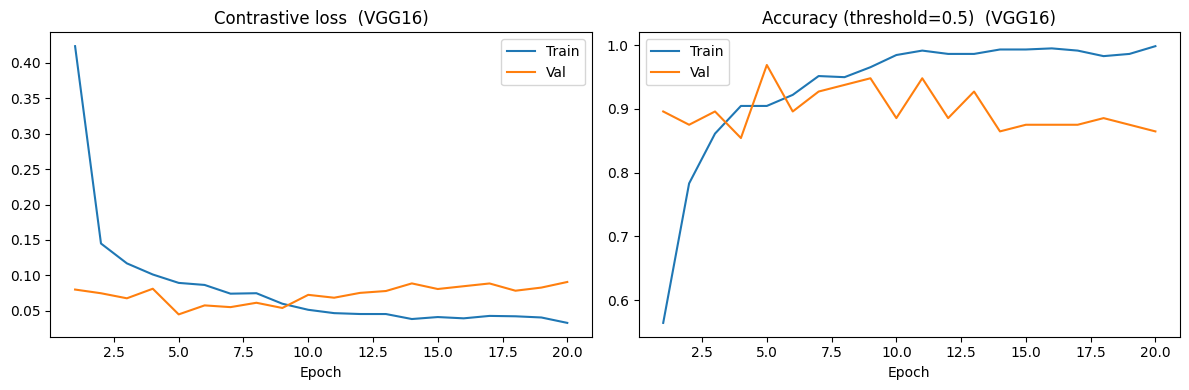

In [24]:
print(f"\nTraining for {CFG['epochs']} epochs...\n")
history = train(model, train_loader, val_loader, CFG)
plot_training_history(history)

### 9.5 Load best checkpoint and find EER threshold

In [25]:
print("\nEvaluating on validation set to find threshold...")
model.load_state_dict(torch.load("best_siamese_vgg16.pth", map_location=device))

val_dists, val_labels = get_distances_and_labels(model, val_loader, device)
threshold = find_best_threshold(val_dists, val_labels)


Evaluating on validation set to find threshold...
EER = 0.014 at threshold = 0.5798


### 9.6 Evaluate on test set

Test accuracy at EER threshold: 0.825


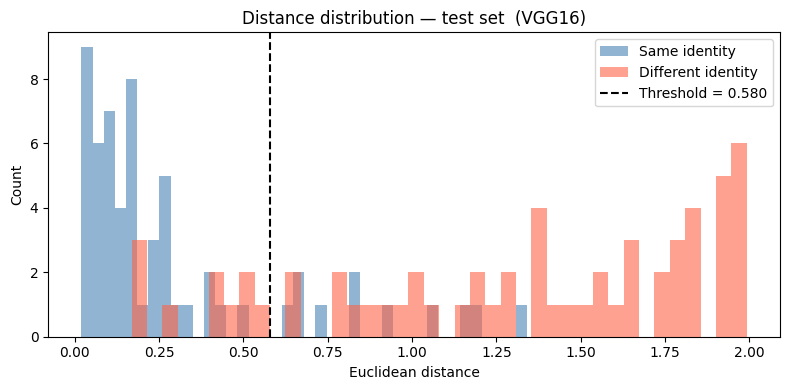

In [26]:
test_dists, test_labels = get_distances_and_labels(model, test_loader, device)
accuracy = ((test_dists < threshold).astype(float) == test_labels).mean()
print(f"Test accuracy at EER threshold: {accuracy:.3f}")

plot_distance_distributions(test_dists, test_labels, threshold)

### 9.7 Quick demo inference

In [27]:
sample_images = test_data[list(test_data.keys())[0]]
if len(sample_images) >= 2:
    verifier = IrisVerifier("best_siamese_vgg16.pth", threshold=threshold)
    print("\nDemo inference:")
    print(f"  {verifier.verify(sample_images[0], sample_images[1])}")

print("\nDone.")


Demo inference:
  {'match': False, 'distance': 0.6599, 'threshold': 0.5797699093818665, 'verdict': 'NO MATCH ✗'}

Done.


## 10. Final Results

### 10.1 Compute metrics (accuracy, FAR, FRR)

In [28]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = test_labels.astype(int)
y_pred = (test_dists < threshold).astype(int)

cm_result = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm_result.ravel()
total = tp + tn + fp + fn
acc   = (tp + tn) / total
far   = fp / (fp + tn) if (fp + tn) > 0 else 0.0
frr   = fn / (fn + tp) if (fn + tp) > 0 else 0.0

print(f"Accuracy : {acc*100:.2f}%")
print(f"FAR      : {far*100:.2f}%  (impostors accepted)")
print(f"FRR      : {frr*100:.2f}%  (genuine users rejected)")
print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}\n")
print(classification_report(y_true, y_pred, target_names=["NO MATCH", "MATCH"]))

Accuracy : 82.50%
FAR      : 16.67%  (impostors accepted)
FRR      : 18.33%  (genuine users rejected)
TP=49  TN=50  FP=10  FN=11

              precision    recall  f1-score   support

    NO MATCH       0.82      0.83      0.83        60
       MATCH       0.83      0.82      0.82        60

    accuracy                           0.82       120
   macro avg       0.83      0.82      0.82       120
weighted avg       0.83      0.82      0.82       120



### 10.2 Plot training curves and confusion matrix

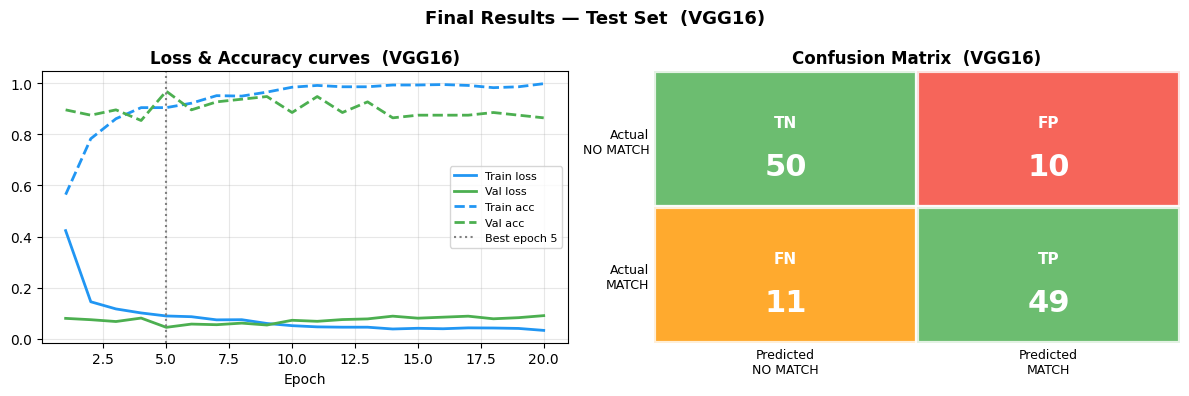

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Final Results — Test Set  (VGG16)", fontsize=13, fontweight="bold")

# left: training curves
epochs  = range(1, len(history["train_loss"]) + 1)
best_ep = int(np.argmin(history["val_loss"])) + 1
ax = axes[0]
ax.plot(epochs, history["train_loss"], label="Train loss",  color="#2196F3", linewidth=2)
ax.plot(epochs, history["val_loss"],   label="Val loss",    color="#4CAF50", linewidth=2)
ax.plot(epochs, history["train_acc"],  label="Train acc",   color="#2196F3", linewidth=2, linestyle="--")
ax.plot(epochs, history["val_acc"],    label="Val acc",     color="#4CAF50", linewidth=2, linestyle="--")
ax.axvline(best_ep, color="gray", linestyle=":", linewidth=1.5, label=f"Best epoch {best_ep}")
ax.set_title("Loss & Accuracy curves  (VGG16)", fontweight="bold")
ax.set_xlabel("Epoch")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# right: confusion matrix
ax = axes[1]
cell_labels = [[f"TN\n{tn}", f"FP\n{fp}"], [f"FN\n{fn}", f"TP\n{tp}"]]
cell_colors = [["#4CAF50", "#f44336"], ["#FF9800", "#4CAF50"]]
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1-i), 1, 1,
                     color=cell_colors[i][j], alpha=0.82, ec="white", lw=3))
        name, val = cell_labels[i][j].split("\n")
        ax.text(j+0.5, 1-i+0.62, name, ha="center", va="center",
                fontsize=11, fontweight="bold", color="white")
        ax.text(j+0.5, 1-i+0.30, val,  ha="center", va="center",
                fontsize=22, fontweight="bold", color="white")

ax.set_xlim(0, 2); ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["Predicted\nNO MATCH", "Predicted\nMATCH"], fontsize=9)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["Actual\nMATCH", "Actual\nNO MATCH"], fontsize=9)
ax.set_title("Confusion Matrix  (VGG16)", fontweight="bold")
for spine in ax.spines.values(): spine.set_visible(False)
ax.tick_params(length=0)

plt.tight_layout()
plt.show()

## 11. Sanity-Check Inference (3 Controlled Scenarios)

In [30]:
def run_verify(verifier, path1, path2, label):
    result = verifier.verify(path1, path2)
    status = "PASS" if (result["match"] == (label == "MATCH")) else "FAIL"
    print(f"  [{status}] Expected {label:8s} | {result['verdict']:12s} | dist={result['distance']:.4f}")
    print(f"         img1: {Path(path1).name}")
    print(f"         img2: {Path(path2).name}")
    print()

In [31]:
# Rebuild identity map and pick test subjects
all_images = parse_dataset(CFG["data_root"])

person_ids = set()
for key in all_images:
    m = re.match(r"(\d+)([LR])", key)
    if m:
        person_ids.add(m.group(1))

bilateral = [pid for pid in person_ids
             if f"{pid}L" in all_images and f"{pid}R" in all_images]
assert bilateral, "No person with both L and R found"

pid1, pid2 = random.sample(bilateral, 2)
imgs_1L = all_images[f"{pid1}L"]
imgs_1R = all_images[f"{pid1}R"]
imgs_2L = all_images[f"{pid2}L"]
assert len(imgs_1L) >= 2, "Need at least 2 images for same-iris test"

Found 128 identities, 384 images total.


In [32]:
verifier = IrisVerifier("best_siamese_vgg16.pth", threshold=threshold)

print("=" * 60)
print("Scenario 1 — same person, same iris (different images) → MATCH")
print("=" * 60)
run_verify(verifier, imgs_1L[0], imgs_1L[1], "MATCH")

print("=" * 60)
print("Scenario 2 — same person, left vs right iris → NO MATCH")
print("=" * 60)
run_verify(verifier, imgs_1L[0], imgs_1R[0], "NO MATCH")

print("=" * 60)
print("Scenario 3 — different people, different iris → NO MATCH")
print("=" * 60)
run_verify(verifier, imgs_1L[0], imgs_2L[0], "NO MATCH")

Scenario 1 — same person, same iris (different images) → MATCH
  [PASS] Expected MATCH    | MATCH ✓      | dist=0.0690
         img1: 010L_1.png
         img2: 010L_2.png

Scenario 2 — same person, left vs right iris → NO MATCH
  [PASS] Expected NO MATCH | NO MATCH ✗   | dist=0.9309
         img1: 010L_1.png
         img2: 010R_1.png

Scenario 3 — different people, different iris → NO MATCH
  [PASS] Expected NO MATCH | NO MATCH ✗   | dist=1.9118
         img1: 010L_1.png
         img2: 016L_1.png



## 12. Custom Photo Test (Your Own Iris Images)

In [33]:
def run_verify_custom(verifier, path1, path2, expected_label):
    result = verifier.verify(str(path1), str(path2))
    passed = (result["match"] == (expected_label == "MATCH"))
    status = "PASS" if passed else "FAIL"
    print(f"  [{status}] Expected {expected_label:8s} | {result['verdict']:12s} | dist={result['distance']:.4f}")
    print(f"         img1: {path1.name}")
    print(f"         img2: {path2.name}")
    print()

In [36]:
CUSTOM_ROOT = Path("/kaggle/input/datasets/alaekh/test-user7/test_user")
verifier    = IrisVerifier("best_siamese_vgg16.pth", threshold=threshold)

print("=" * 60)
print("Test 1 — al1.jpg vs al2.jpg (same person, same iris) → MATCH")
print("=" * 60)
run_verify_custom(verifier,
    CUSTOM_ROOT / "al1.jpg",
    CUSTOM_ROOT / "al2.jpg",
    "MATCH")

print("=" * 60)
print("Test 2 — ak1.jpg vs al1.jpg (different people) → NO MATCH")
print("=" * 60)
run_verify_custom(verifier,
    CUSTOM_ROOT / "ak1.jpg",
    CUSTOM_ROOT / "al1.jpg",
    "NO MATCH")

Test 1 — al1.jpg vs al2.jpg (same person, same iris) → MATCH
  [PASS] Expected MATCH    | MATCH ✓      | dist=0.0278
         img1: al1.jpg
         img2: al2.jpg

Test 2 — ak1.jpg vs al1.jpg (different people) → NO MATCH
  [FAIL] Expected NO MATCH | MATCH ✓      | dist=0.1423
         img1: ak1.jpg
         img2: al1.jpg

